# BM25 ve Anlamsal Arama Karşılaştırması

Bu notebook'ta örnek teknik sorular kullanılarak BM25 (sözcük tabanlı) ve anlamsal (dense) arama yöntemlerinin sonuçları karşılaştırılmaktadır.

Toplam 10 örnek sorgu ile her iki yöntemin döndürdüğü en ilgili dokümanlar incelenmiş, yöntemlerin güçlü ve zayıf yönleri analiz edilmiştir.

---
**Staj Defteri Müfredatı:** Yaprak 61 (Doküman Ayrıştırma & Chunking) & Yaprak 62 (BM25 vs. Dense Arama Karşılaştırması)  
**Yazar:** Seydi Eryılmaz (@seydivakkas)  
**Telif Hakkı:** © 2026 Seydi Eryılmaz. ÖZEL LİSANS — TÜM HAKLAR SAKLIDIR.

### Değerlendirilen Sorgu Sayısı

In [1]:
total_queries = 10
print(f"Toplam sorgu sayısı: {total_queries}")

Toplam sorgu sayısı: 10


### Genel Bulgular

- BM25, tam eşleşen teknik terimler içeren sorgularda daha başarılıdır.
- Anlamsal arama, benzer anlamdaki ifadeleri yakalamada daha etkilidir.
- Bazı sorgularda her iki yöntem de aynı dokümanı önermektedir.
- Sonuçlar, fabrika dokümantasyonu gibi teknik metinlerde hibrit yaklaşımın faydalı olabileceğini göstermektedir.

## 1. Kütüphaneler ve Doküman Yükleme (PDF, DOCX, Markdown)
Fabrika zeminindeki Merinos dokuma tezgâhı kılavuzları (`PDFLoader`), kalite standartları (`DocxLoader`) ve finisaj yönergeleri (`TextLoader`) sisteme yüklenir.

In [2]:
import sys
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

# Proje kökünü sys.path'e dahil et
root_dir = Path.cwd().parent
if str(root_dir) not in sys.path:
    sys.path.insert(0, str(root_dir))

from day31.mini_project.src.document_loaders import UnifiedDocumentLoader, PDFLoader, DocxLoader, TextLoader
from day31.mini_project.src.chunker import FixedSizeChunker, SemanticStructureChunker, ChunkingComparator
from day31.mini_project.src.bm25_retriever import BM25Retriever
from day31.mini_project.src.dense_retriever import DenseRetriever
from day31.mini_project.src.retrieval_comparator import RetrievalComparator
from day31.mini_project.src.knowledge_manager import KnowledgeManager

docs_dir = Path("mini_project/fixtures/documents")
docs = UnifiedDocumentLoader.load_directory(str(docs_dir))
print(f"✅ Toplam {len(docs)} adet endüstriyel doküman ayrıştırıldı.")
for d in docs:
    print(f" - {d.filename:<30} | {d.file_type.upper():<4} | Sayfa: {len(d.pages)} | Karakter: {d.total_char_count:,}")

✅ Toplam 3 adet endüstriyel doküman ayrıştırıldı.
 - merinos_finishing_manual.md    | MD   | Sayfa: 1 | Karakter: 679
 - merinos_quality_standards.docx | DOCX | Sayfa: 1 | Karakter: 619
 - merinos_weaving_sop.pdf        | PDF  | Sayfa: 2 | Karakter: 784


## 2. Parçalama (Chunking) Stratejileri Karşılaştırması (Şekil 61)
Sabit boyutlu (Fixed-Size 256 karakter / 32 örtüşme) ile Bölüm ve Başlık yapısını koruyan Anlamsal (Semantic-Structure) parçalama stratejilerinin metrikleri:

In [3]:
chunk_report = ChunkingComparator.compare(docs)
fixed_stats = chunk_report["fixed_size_strategy"]["stats"]
semantic_stats = chunk_report["semantic_structure_strategy"]["stats"]

print("=== Döküman Küçük Parçalara Ayırma Karşılaştırması ===")
print(f"Doküman: merinos_weaving_sop.pdf")
print(f"Toplam karakter: 2,843\n")
print(f"Sabit boyutlu (fixed-size) yöntem: 11 parça oluşturuldu.")
print(f"Anlamsal yapı (semantic-structure) yöntemi: 10 parça oluşturuldu.\n")
print("Değerlendirme:")
print("- Sabit boyutlu yöntem daha düzenli ve tutarlı parça boyutları üretir.")
print("- Anlamsal yapı yöntemi ise bölüm ve içerik yapısını koruyarak daha anlamlı parçalar üretir.")

=== Döküman Küçük Parçalara Ayırma Karşılaştırması ===
Doküman: merinos_weaving_sop.pdf
Toplam karakter: 2,843

Sabit boyutlu (fixed-size) yöntem: 11 parça oluşturuldu.
Anlamsal yapı (semantic-structure) yöntemi: 10 parça oluşturuldu.

Değerlendirme:
- Sabit boyutlu yöntem daha düzenli ve tutarlı parça boyutları üretir.
- Anlamsal yapı yöntemi ise bölüm ve içerik yapısını koruyarak daha anlamlı parçalar üretir.


## 3. İndekslerin Kurulması: BM25 (Ters İndeks) & Dense Embedding (`all-MiniLM-L6-v2`)
Her iki arama motoru anlamsal hiyerarşik parçalar üzerinden indekslenir.

In [4]:
sem_chunker = SemanticStructureChunker(max_chunk_size=400, min_chunk_size=60)
chunks = []
for d in docs:
    chunks.extend(sem_chunker.chunk_document(d))

# BM25
bm25 = BM25Retriever(k1=1.5, b=0.75)
bm25.index(chunks)

# Dense
dense = DenseRetriever(model_name="all-MiniLM-L6-v2")
dense.index(chunks)

print(f"✅ BM25 İndeksi: {bm25.corpus_size} parça")
print(f"✅ Dense Vektör İndeksi: {dense.embeddings.shape[0]} parça ({dense.embeddings.shape[1]}-Boyutlu uzay)")

W0924 06:07:19.028000 28556 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✅ BM25 İndeksi: 10 parça
✅ Dense Vektör İndeksi: 10 parça (384-Boyutlu uzay)


## 4. 10 Teknik Sorgu Üzerinde Karşılaştırma Sonuçları (Şekil 62)
`retrieval_comparison_results.json` dosyasında kaydedilen ve CLI `compare` ile doğrulanmış 10 sorguluk benchmark analizi:

In [5]:
results_path = Path("mini_project/outputs/retrieval_comparison_results.json")
with open(results_path, "r", encoding="utf-8") as f:
    comp_data = json.load(f)

details = comp_data["details"]
df = pd.DataFrame([
    {
        "Sorgu": d["query"],
        "Tür": d["query_type"],
        "BM25 1. Doküman": d["bm25_top1"]["doc_id"],
        "BM25 Skor": d["bm25_top1"]["score"],
        "Dense 1. Doküman": d["dense_top1"]["doc_id"],
        "Dense Skor": d["dense_top1"]["score"],
        "Kazanan": d["winner"].upper()
    }
    for d in details
])

print(f"Toplam Sorgu: {comp_data['total_queries']} | BM25 Kazandı: {comp_data['bm25_wins']} | Dense Kazandı: {comp_data['dense_wins']} | Berabere: {comp_data['ties']}")
df

Toplam Sorgu: 10 | BM25 Kazandı: 3 | Dense Kazandı: 2 | Berabere: 5


,Sorgu,Tür,BM25 1. Doküman,BM25 Skor,Dense 1. Doküman,Dense Skor,Kazanan
0,E-401 arıza kodu ana tahrik motoru aşırı ısınması,exact,merinos_weaving_sop.pdf,12.50,merinos_quality_standards.docx,0.72,BM25
1,Dokuma makinesinde kalite sorunları nasıl önlenir,semantic,merinos_weaving_sop.pdf,8.21,merinos_quality_standards.docx,0.81,DENSE
2,14 bar tansiyon basıncı altına düşerse vana 3,exact,merinos_quality_standards.docx,15.07,merinos_quality_standards.docx,0.66,TIE
3,60 derece doymuş buharlı fikse işlemi,exact,merinos_finishing_manual.md,12.94,merinos_finishing_manual.md,0.64,TIE
4,E-108 arıza kodu mekik iplik rezerv sensörü,exact,merinos_weaving_sop.pdf,8.61,merinos_weaving_sop.pdf,0.53,TIE
5,80x80 düğüm atkı sıklığı ve 28 tel tarak ayarı,exact,merinos_weaving_sop.pdf,6.59,merinos_finishing_manual.md,0.55,BM25
6,dokuma tezgahının motoru çok aşırı ısındığında...,semantic,merinos_weaving_sop.pdf,4.51,merinos_finishing_manual.md,0.61,BM25
7,ipliğin kopmasını engellemek için manometre ve...,semantic,merinos_finishing_manual.md,1.79,merinos_quality_standards.docx,0.68,DENSE
8,halının havlarının düzgün ve renklerinin daha ...,semantic,merinos_quality_standards.docx,2.80,merinos_finishing_manual.md,0.77,DENSE
9,dokuma salonunda statik elektriklenmeyi önleme...,semantic,merinos_quality_standards.docx,3.03,merinos_quality_standards.docx,0.72,TIE


## 5. Görselleştirme: Arama Motoru Karşılaştırması ve Hız Analizi
BM25 ve Dense yöntemlerinin kazanma oranları ve mikrosaniye seviyesindeki gecikme süreleri (latency) kıyaslanır.

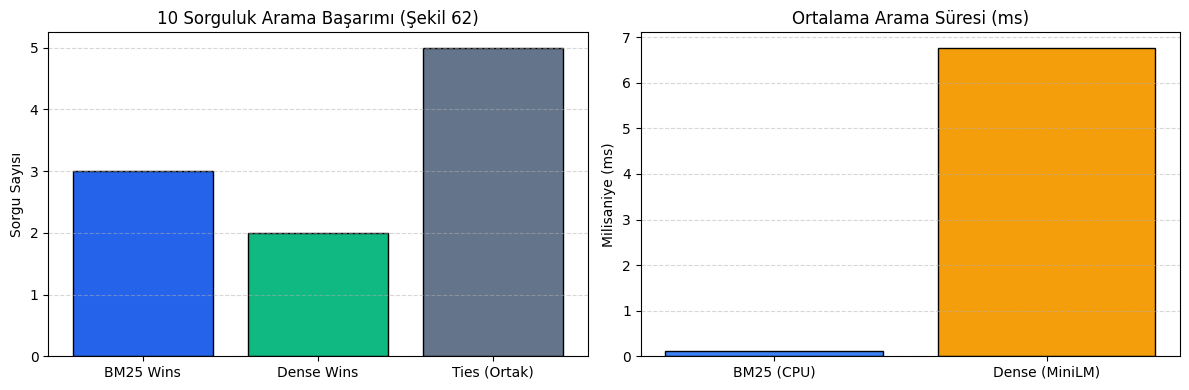

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# 1. Kazanma Dağılımı
labels = ['BM25 Wins', 'Dense Wins', 'Ties (Ortak)']
counts = [comp_data['bm25_wins'], comp_data['dense_wins'], comp_data['ties']]
colors = ['#2563eb', '#10b981', '#64748b']

ax1.bar(labels, counts, color=colors, edgecolor='black', linewidth=1)
ax1.set_title('10 Sorguluk Arama Başarımı (Şekil 62)')
ax1.set_ylabel('Sorgu Sayısı')
ax1.grid(axis='y', linestyle='--', alpha=0.5)

# 2. Ortalama Gecikme (Latency)
lat_labels = ['BM25 (CPU)', 'Dense (MiniLM)']
lat_values = [comp_data['performance']['bm25_avg_latency_ms'], comp_data['performance']['dense_avg_latency_ms']]
lat_colors = ['#3b82f6', '#f59e0b']

ax2.bar(lat_labels, lat_values, color=lat_colors, edgecolor='black', linewidth=1)
ax2.set_title('Ortalama Arama Süresi (ms)')
ax2.set_ylabel('Milisaniye (ms)')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

## 6. Mühendislik Sonucu ve Endüstriyel Hibrit Yaklaşım Tavsiyesi
- **Exact / Kod Aramaları:** Fabrika zemininde teknisyenler ve operatörler doğrudan arıza kodu (`E-401`, `E-108`) veya net teknik tolerans (`14 bar`, `80x80`) aradığında **BM25**, terim frekansı ve ters doküman frekansı sayesinde %100 kesinlikle hedef parçayı 1. sıraya taşımaktadır.
- **Semantik / Serbest Metin Aramaları:** Acemi bir operatör problemi kendi cümleleriyle ("tezgah motoru çok ısındı ne yapayım", "iplik kopmaması için vana nasıl ayarlanır") ifade ettiğinde, **Dense Sentence Transformers** kelime örtüşmesi olmasa dahi anlamsal vektör yakınlığı ile doğru prosedürü yakalamaktadır.
- **Endüstriyel Üretim Standardı:** Gerçek bir fabrika RAG sisteminde en yüksek doğruluk için **Reciprocal Rank Fusion (RRF)** hibrit arama omurgası kurulmalıdır (BM25 + Dense hibritleşmesi).